### This notebook is for doing an EDA of the Louisville Metro Animal Services (LMAS) intake and outcome data, which can be found here: https://data.louisvilleky.gov/datasets/733145c30ad94d43bdc6aba7fd0fdb09_0/explore. The date I pulled my data was 12/03/2025.

In [2]:
import pandas as pd

In [3]:
lmas_df = pd.read_csv('../data/animal_intake_data_2025.12.03.csv')

lmas_df.head()

,kennel,animalid,jurisdiction,intype,insubtype,indate,surreason,outtype,outsubtype,outdate,animaltype,sex,bites,petsize,color,breed,sourcezipcode,ObjectId
0,INTAKE,A430999,40204,OWNER SUR,EUTH REQ,2021-01-07 00:00:00,EUTH MED,EUTH,REQUESTED,2021-01-07 00:00:00,DOG,N,N,LARGE,WHITE / TAN,BASSET HOUND,40204,1
1,FOSTER,A423884,40211,STRAY,OTC,2025-03-07 00:00:00,STRAY,FOSTER,STRAY,2025-03-12 00:00:00,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213,2
2,FOSTER,A423884,40213,FOSTER,RETURN,2025-04-13 00:00:00,FOSTER RET,ADOPTION,FOSTER,2025-04-13 00:00:00,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213,3
3,N47,A583388,40228,OWNER SUR,OTC,2025-05-05 00:00:00,OWNER MED,ADOPTION,WALK IN,2025-05-20 00:00:00,CAT,N,N,X-LRG,ORANGE,DOMESTIC SH,40228,4
4,FREEZER,A558504,40215,STRAY,FIELD,2022-02-21 00:00:00,DOA,DISPOSAL,NECROPSY,2022-03-09 00:00:00,DOG,N,N,MED,BLUE,AMERICAN STAFF / MIX,40218,5


In [4]:
lmas_df.columns

Index(['kennel', 'animalid', 'jurisdiction', 'intype', 'insubtype', 'indate',
       'surreason', 'outtype', 'outsubtype', 'outdate', 'animaltype', 'sex',
       'bites', 'petsize', 'color', 'breed', 'sourcezipcode', 'ObjectId'],
      dtype='str')

In [5]:
lmas_df = lmas_df.drop('ObjectId', axis=1)

In [6]:
lmas_df.dtypes

kennel           str
animalid         str
jurisdiction     str
intype           str
insubtype        str
indate           str
surreason        str
outtype          str
outsubtype       str
outdate          str
animaltype       str
sex              str
bites            str
petsize          str
color            str
breed            str
sourcezipcode    str
dtype: object

In [7]:
lmas_df['indate'] = pd.to_datetime(lmas_df['indate'])
lmas_df['outdate'] = pd.to_datetime(lmas_df['outdate'])

In [8]:
lmas_df.dtypes

kennel                      str
animalid                    str
jurisdiction                str
intype                      str
insubtype                   str
indate           datetime64[us]
surreason                   str
outtype                     str
outsubtype                  str
outdate          datetime64[us]
animaltype                  str
sex                         str
bites                       str
petsize                     str
color                       str
breed                       str
sourcezipcode               str
dtype: object

In [9]:
duplicate_counts = lmas_df.apply(lambda x: x.duplicated(keep=False).sum())
print(duplicate_counts)

kennel           64658
animalid         23432
jurisdiction     64668
intype           64668
insubtype        64668
indate           64668
surreason        64666
outtype          64668
outsubtype       64659
outdate          64661
animaltype       64668
sex              64668
bites            64668
petsize          64668
color            64550
breed            64262
sourcezipcode    64421
dtype: int64


In [10]:
lmas_df[lmas_df.duplicated(['animalid'], keep=False)]

,kennel,animalid,jurisdiction,intype,insubtype,indate,surreason,outtype,outsubtype,outdate,animaltype,sex,bites,petsize,color,breed,sourcezipcode
1,FOSTER,A423884,40211,STRAY,OTC,2025-03-07,STRAY,FOSTER,STRAY,2025-03-12,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213
2,FOSTER,A423884,40213,FOSTER,RETURN,2025-04-13,FOSTER RET,ADOPTION,FOSTER,2025-04-13,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213
10,N16,A688292,40218,STRAY,FIELD,2021-01-19,STRAY,FOSTER,NaN,2021-03-21,DOG,S,N,MED,BROWN / WHITE,PIT BULL,40218
20,308,A688944,40214,STRAY,OTC,2021-02-05,STRAY,RTO,IN KENNEL,2021-02-09,DOG,S,N,LARGE,TAN / WHITE,GERM SHEPHERD / LABRADOR RETR,40214
21,N34,A689013,40212,STRAY,FIELD,2021-05-28,ABANDON,ADOPTION,INTERNET,2021-06-22,DOG,S,N,MED,GRAY,PIT BULL,40218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64651,FOSTER,A782748,40218,STRAY,OTC,2025-06-17,STRAY,FOSTER,STRAY,2025-06-22,DOG,S,N,SMALL,BRN MERLE,DACHSHUND,40291
64652,FOSTER,A782748,40218,FOSTER,RETURN,2025-08-01,STRAY,FOSTER,VACATION,2025-08-01,DOG,S,N,SMALL,BRN MERLE,DACHSHUND,40222
64653,FOSTER,A782748,40218,FOSTER,RETURN,2025-08-07,STRAY,TRANSFER,RESCUE GRP,2025-08-09,DOG,S,N,SMALL,BRN MERLE,DACHSHUND,40258
64655,N06,A768118,40299,FOSTER,RETURN,2024-11-09,FOSTER RET,ADOPTION,FACEBOOK,2024-11-09,DOG,S,N,MED,BR BRINDLE,PIT BULL,40211


As stated in my previous project, the animal ID appears to be duplicated when an animal is returned or found after adoption, so I don't want to discard the duplicates.

In [11]:
lmas_df.isnull().sum()

kennel               0
animalid             0
jurisdiction     13450
intype               0
insubtype          182
indate               0
surreason        13450
outtype          13790
outsubtype       23311
outdate          13755
animaltype           0
sex               1039
bites            13434
petsize           2453
color                1
breed               77
sourcezipcode     9591
dtype: int64

Animal id is never null, nor is intype, indate, or animal type, so I don't think I want to discard any nulls. I will go ahead and fill them in with the following values:

jurisdiction: unknown

insubtype: none

surreason: unknown

outtype: unknown

outsubtype: none

outdate: pd.NaT

sex: unknown

bites: unknown

petsize: unknown

color: unknown

breed: unknown

sourcezipcode: unknown

In [12]:
lmas_df['jurisdiction'].fillna("unknown")
lmas_df['insubtype'].fillna('none')
lmas_df['surreason'].fillna('unknown')
lmas_df['outtype'].fillna('unknown')
lmas_df['outsubtype'].fillna('none')
lmas_df['outdate'].fillna(pd.NaT)
lmas_df['sex'].fillna('unknown')
lmas_df['bites'].fillna('unknown')
lmas_df['petsize'].fillna('unknown')
lmas_df['color'].fillna('unknown')
lmas_df['breed'].fillna('unknown')
lmas_df['sourcezipcode'].fillna('unknown')

0          40204
1          40213
2          40213
3          40228
4          40218
          ...   
64663    unknown
64664      40219
64665      40229
64666      40214
64667      40205
Name: sourcezipcode, Length: 64668, dtype: str

In [ ]:
lmas_df.rename(columns={
    'animalid': 'animal_id',
    'intype': 'intake_type',
    'insubtype': 'intake_subtype',
    'indate': "intake_date",
    'surreason': 'surrender_reason',
    'outtype': 'out_type',
    'outsubtype': 'out_subtype',
    'outdate': 'out_date',
    'animaltype': "animal_type",
    'petsize': 'size',
    'sourcezipcode': "source_zip_code"
}, inplace=True)

lmas_df.head()

,kennel,animal_id,jurisdiction,intake_type,intake_subtype,intake_date,surrender_reason,out_type,out_subtype,out_date,animal_type,sex,bites,size,color,breed,source_zip_code
0,INTAKE,A430999,40204,OWNER SUR,EUTH REQ,2021-01-07,EUTH MED,EUTH,REQUESTED,2021-01-07,DOG,N,N,LARGE,WHITE / TAN,BASSET HOUND,40204
1,FOSTER,A423884,40211,STRAY,OTC,2025-03-07,STRAY,FOSTER,STRAY,2025-03-12,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213
2,FOSTER,A423884,40213,FOSTER,RETURN,2025-04-13,FOSTER RET,ADOPTION,FOSTER,2025-04-13,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213
3,N47,A583388,40228,OWNER SUR,OTC,2025-05-05,OWNER MED,ADOPTION,WALK IN,2025-05-20,CAT,N,N,X-LRG,ORANGE,DOMESTIC SH,40228
4,FREEZER,A558504,40215,STRAY,FIELD,2022-02-21,DOA,DISPOSAL,NECROPSY,2022-03-09,DOG,N,N,MED,BLUE,AMERICAN STAFF / MIX,40218


#### Grouping and aggregating data after basic clean-up, plus some visuals:

In [14]:
animal_type_count = lmas_df['animal_type'].value_counts()
animal_type_count

animal_type
DOG           33652
CAT           30051
RABBIT          358
OTHER           335
BIRD            182
LIVESTOCK        62
GUINEA PIG       28
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt

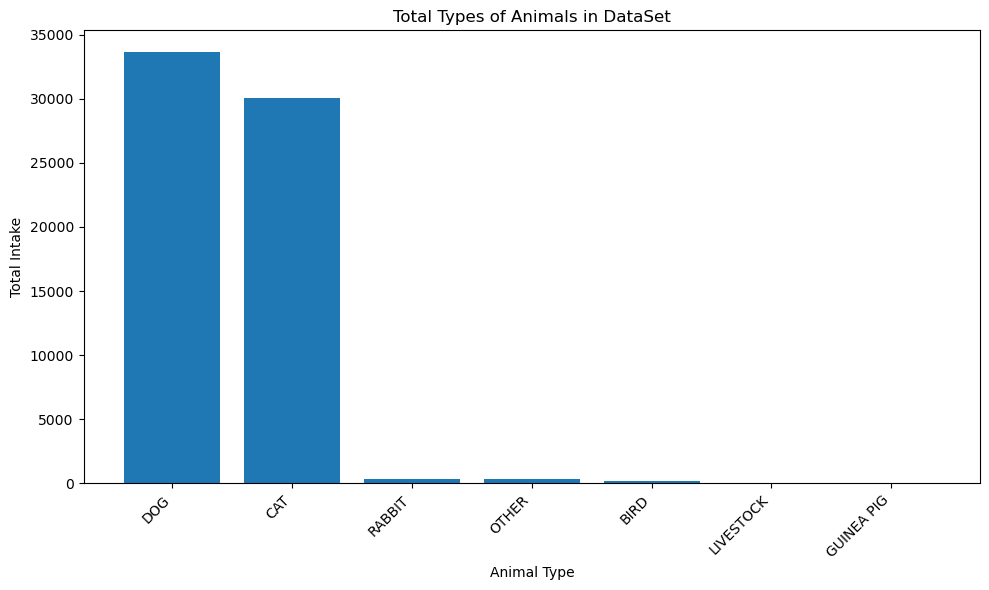

In [16]:
plt.figure(figsize=(10, 6))

color = "#2702AD"

plt.bar(animal_type_count.index, animal_type_count.values)

plt.xlabel('Animal Type')
plt.ylabel("Total Intake")
plt.title("Total Types of Animals in DataSet")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [17]:
breed_groups = lmas_df.groupby(['animal_type', 'breed']).size()
breed_groups

animal_type  breed              
BIRD         ARAUCANA / AMERICAN     1
             BANTAM                  2
             BUDGERIGAR              2
             CHICKEN                79
             COCKATIEL               3
                                    ..
RABBIT       REX                    37
             REX-MINI                3
             SATIN                   4
             TAN                     2
             THRIANTA                2
Length: 1348, dtype: int64

In [18]:
target_animal = 'dog'
lmas_df['animal_type'] = lmas_df['animal_type'].str.strip().str.lower()

dog_filtered_df = lmas_df[lmas_df['animal_type'] == target_animal]

dog_breed_counts = dog_filtered_df['breed'].value_counts()
dog_breed_counts

breed
PIT BULL                           5603
GERM SHEPHERD                      1714
PIT BULL / MIX                     1526
LABRADOR RETR                      1351
LABRADOR RETR / MIX                1087
                                   ... 
RAT TERRIER / LABRADOR RETR           1
ALASK MALAMUTE / SIBERIAN HUSKY       1
CAIRN TERRIER / SCHNAUZER STAND       1
PIT BULL / AUST SHEPHERD              1
ALASKAN HUSKY / BASENJI               1
Name: count, Length: 1180, dtype: int64

In [19]:
dog_breed_counts_25 = dog_breed_counts.head(25)

There are 1180 breeds of dog, so I'm going to take the top 25 breeds and graph them.

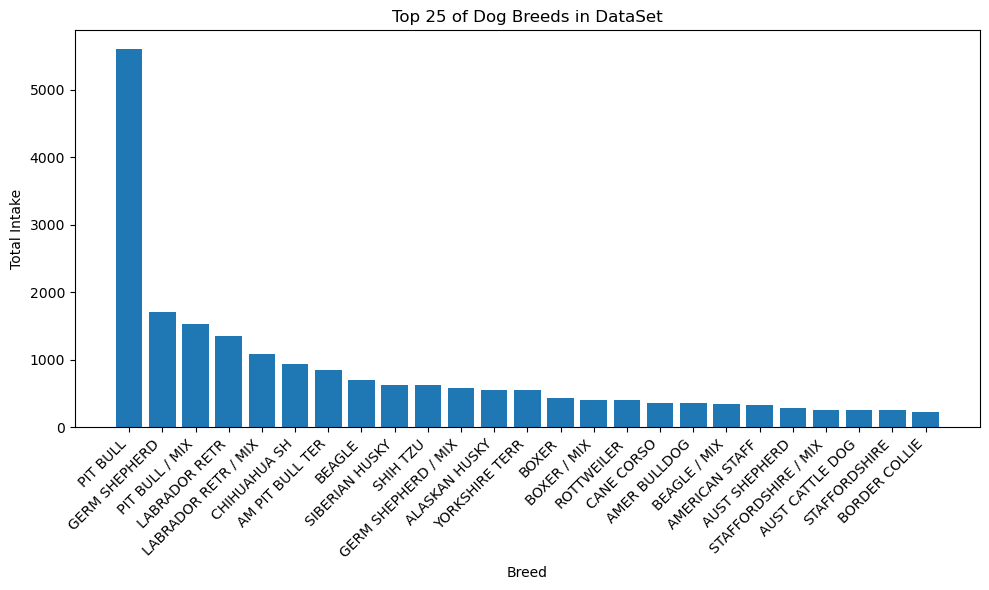

In [20]:
plt.figure(figsize=(10, 6))

color = "#2702AD"

plt.bar(dog_breed_counts_25.index, dog_breed_counts_25.values)

plt.xlabel('Breed')
plt.ylabel("Total Intake")
plt.title("Top 25 of Dog Breeds in DataSet")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Pitbulls lead by a lot.

In [21]:
target_animal_cat = 'cat'
lmas_df['animal_type'] = lmas_df['animal_type'].str.strip().str.lower()

cat_filtered_df = lmas_df[lmas_df['animal_type'] == target_animal_cat]

cat_breed_counts = cat_filtered_df['breed'].value_counts()
cat_breed_counts

breed
DOMESTIC SH                  23940
DOMESTIC MH                   2273
DOMESTIC LH                   1232
AMER SH                       1168
SIAMESE                        270
                             ...  
SINGAPURA                        1
DOMESTIC MH / DOMESTIC MH        1
SIAMESE / DOMESTIC MH            1
PERSIAN / MIX                    1
ORIENTAL SH / MIX                1
Name: count, Length: 90, dtype: int64

Similar to dogs, I'm going to take the top 25:

In [22]:
cat_breed_counts_25 = cat_breed_counts.head(25)

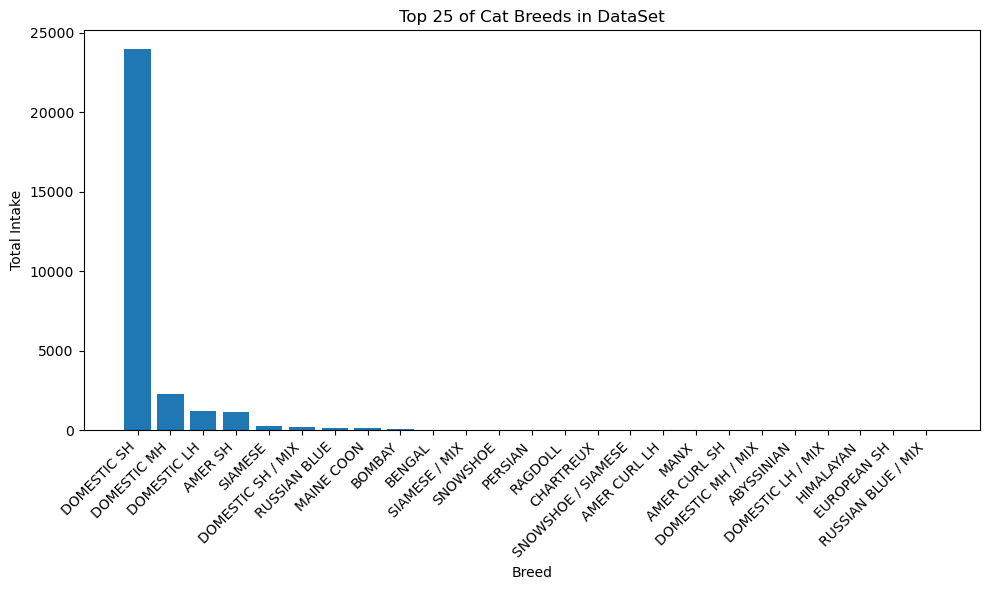

In [23]:
plt.figure(figsize=(10, 6))

color = "#2702AD"

plt.bar(cat_breed_counts_25.index, cat_breed_counts_25.values)

plt.xlabel('Breed')
plt.ylabel("Total Intake")
plt.title("Top 25 of Cat Breeds in DataSet")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

I don't think the cat one is useful- domestic shorthair can mean a lot, so maybe by color would make more sense.

In [24]:
target_animal_cat = 'cat'
lmas_df['animal_type'] = lmas_df['animal_type'].str.strip().str.lower()

cat_filtered_df = lmas_df[lmas_df['animal_type'] == target_animal_cat]

cat_color_counts = cat_filtered_df['color'].value_counts()
cat_color_counts

color
BLACK                   4726
UNKNOWN                 3302
BRN TABBY               3110
BLACK / WHITE           2541
GRAY TABBY              1644
                        ... 
BLK TIGER / BROWN          1
CALICO / BROWN             1
LYNX PT / GRAY             1
BLUE / BLUE TABBY          1
GRAY TABBY / APRICOT       1
Name: count, Length: 335, dtype: int64

In [25]:
cat_color_counts_25 = cat_color_counts.head(25)

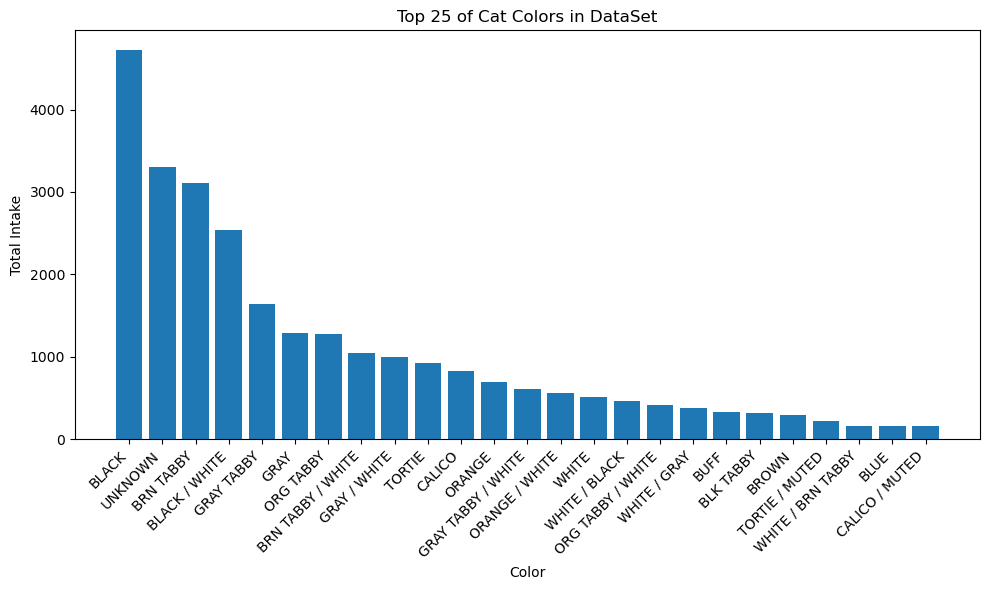

In [26]:
plt.figure(figsize=(10, 6))

color = "#2702AD"

plt.bar(cat_color_counts_25.index, cat_color_counts_25.values)

plt.xlabel('Color')
plt.ylabel("Total Intake")
plt.title("Top 25 of Cat Colors in DataSet")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Black leads by a lot.

Reoccurence of animal ID:

In [27]:
animal_ids_count = lmas_df['animal_id'].value_counts(ascending=False)
animal_ids_repeated = animal_ids_count[animal_ids_count > 1]
animal_ids_repeated

animal_id
A742781    12
A699289     9
A727610     8
A732871     8
A728833     8
           ..
A782687     2
A785886     2
A785890     2
A782373     2
A774843     2
Name: count, Length: 10388, dtype: int64

In [28]:
target_value = 'A742781'
filtered_df = lmas_df[lmas_df['animal_id'] == target_value]
print(filtered_df)

         kennel animal_id jurisdiction intake_type intake_subtype intake_date  \
37097      BARN   A742781        40205      RETURN       ADOPTION  2024-02-12   
37098  FOLLOWUP   A742781        40214      RETURN       ADOPTION  2023-11-30   
37762    FOSTER   A742781        40291       STRAY            OTC  2023-08-01   
37763    FOSTER   A742781        40291      FOSTER         RETURN  2023-08-29   
37764       N17   A742781        40218      RETURN       ADOPTION  2023-11-01   
37765       N06   A742781        40229      FOSTER         RETURN  2023-09-23   
38614        NP   A742781        40229      FOSTER         RETURN  2024-02-09   
38615      BARN   A742781        40205      FOSTER         RETURN  2024-03-23   
38616       412   A742781        40291      RETURN       ADOPTION  2024-04-05   
38617       101   A742781        40229      FOSTER         RETURN  2024-04-30   
38618  FOLLOWUP   A742781        40229      RETURN       ADOPTION  2024-01-16   
38619       N17   A742781   

A742781 seems to be the same animal and is repeatedly listed 12 times, with different intake and out dates. The breed, sex, size, and color match. Because of this, I don't think animal IDs are reused among different animals. This indicates to me that calculating the return rate is possible. I'd like to figure out the return rate for the year 2024.

In [29]:
def intake_over_year(year): 
    intake_year = lmas_df.groupby(lmas_df['intake_date'].dt.year)['animal_id'].value_counts()

    filtered_intake_year = intake_year.loc[int(year)]

    return filtered_intake_year

filtered_intake_year_2024 = intake_over_year(2024)

filtered_intake_year_2024

animal_id
A754031    7
A742781    6
A756774    6
A763405    6
A751249    6
          ..
A768360    1
A768332    1
A768029    1
A623406    1
A673163    1
Name: count, Length: 11563, dtype: int64

In [30]:
def filtered_intake_year_repeats(year):
    intake_year = lmas_df.groupby(lmas_df['intake_date'].dt.year)['animal_id'].value_counts()

    filtered_intake_year = intake_year.loc[int(year)]

    filtered_intake_year_repeats_count = filtered_intake_year[filtered_intake_year > 1]

    return filtered_intake_year_repeats_count

filtered_intake_year_2024_repeats = filtered_intake_year_repeats(2024)

filtered_intake_year_2024_repeats

animal_id
A754031    7
A742781    6
A756774    6
A763405    6
A751249    6
          ..
A764883    2
A765111    2
A771768    2
A771983    2
A759113    2
Name: count, Length: 2346, dtype: int64

In [31]:
def return_rate(year):
    return len(filtered_intake_year_repeats(year)) / len(intake_over_year(year)) * 100

return_rate_2024 = return_rate(2024)
return_rate_2024

20.288852373951396

The return rate for 2024 is 20.29%. I figured out the return rate by taking the amount of repeated animal IDs divided by the number of intakes total times 100. Let's see how that compares for other years and chart it.

In [32]:
return_rate_2021 = return_rate(2021)
print(return_rate_2021)

return_rate_2022 = return_rate(2022)
print(return_rate_2022)

return_rate_2023 = return_rate(2023)
print(return_rate_2023)

return_rate_2024 = return_rate(2024)
print(return_rate_2024)

14.370418283742993
13.75997099347353
13.900033433634237
20.288852373951396


In [33]:
def get_return_rates(start, end):
    dict_of_return_rates = {}
    for year in range(start, end + 1):
            rate = return_rate(year)
            dict_of_return_rates[int(year)] = rate
    return dict_of_return_rates

return_rates_2021_2024 = get_return_rates(2021, 2024)

df_return_rates = pd.DataFrame.from_dict(return_rates_2021_2024, orient='index')
df_return_rates

,0
2021,14.370418
2022,13.759971
2023,13.900033
2024,20.288852


#### Return and Adoption Rates at Louisville Metro Animal Services from 2021 - 2024

Even though my data goes through almost the entire year of 2025, my census data only goes through 2024, so I will only use 2021-2024.

(0.0, 50.0)

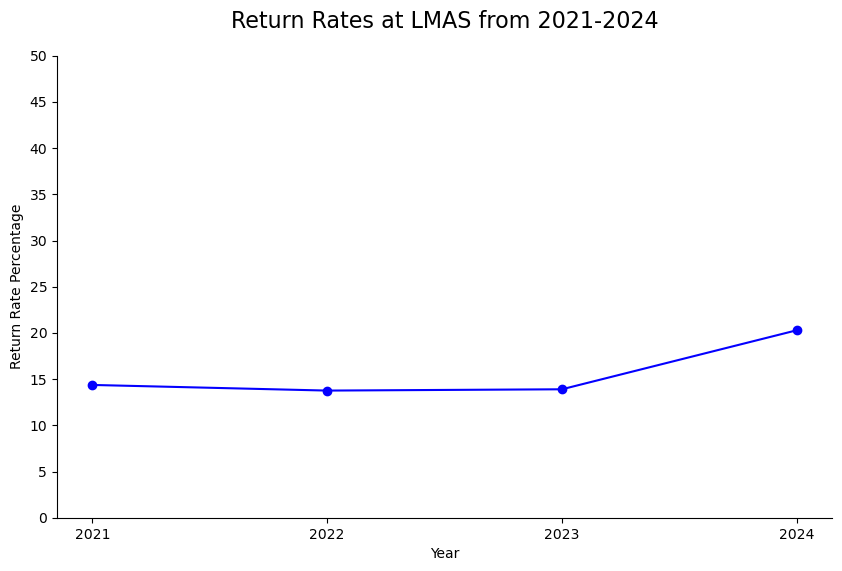

In [34]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6))

plt.plot(df_return_rates.index, df_return_rates.values, color="#0400ff", marker='o')


plt.xlabel("Year")
plt.ylabel("Return Rate Percentage")
plt.title("Return Rates at LMAS from 2021-2024", fontsize=16, pad=20)


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1.0))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=5.0))


plt.ylim(0, 50)


The Return Rate is an important metric, as it informs us of how successful adopting out an animal is. There have been news articles recently about the return rate increasing since the massive adoption wave in 2020. However, I don't have data prior to 2021, so I'm unsure of how true that is for the Louisville area. It is true that so far the return rate is trending upward, as demonstrated by the above graph.

I chose a line graph for this data because it shows trends over time better, and I chose a saturated blue because Louisville Metro Government tends to use blue and yellow for their colors. I made sure to label my y-axis as a percentage, and decided to truncate it at 50% since none of the data points go above 25%. I felt that using 25% instead of 50% would produce too dramatic of a line, and that 100% had a lot of wasted space.

For the data, I did some cursory research on average return rates at animal shelters across the United States, and it seems like 15-20% is a little high but normal. Ideally most shelters want their return rate to be around 10%.

Next I'd like to figure out the rate of adoption from 2021 - 2024 and compare it to the return rate.

In [35]:
def out_types_by_year_and_type(year, out_types):
    lmas_df['out_type'] = lmas_df['out_type'].str.strip().str.lower()
    out_type_count = lmas_df.groupby(lmas_df['out_date'].dt.year)['out_type'].value_counts(ascending=False)

    filtered_out_type_by_year = out_type_count.loc[int(year)]
    filtered_out_type_by_type = filtered_out_type_by_year.loc[str(out_types)]
    filtered_out_type_by_year_sum = filtered_out_type_by_year.sum()
    return filtered_out_type_by_type, filtered_out_type_by_year_sum

out_types_by_year_and_type(2024, 'adoption')

(np.int64(3666), np.int64(11470))

In [36]:
def adoption_out_type_by_year(year):
    lmas_df['out_type'] = lmas_df['out_type'].str.strip().str.lower()
    out_types_count = lmas_df.groupby(lmas_df['out_date'].dt.year)['out_type'].value_counts(ascending=False)
    year_count = out_types_count.loc[year]
    adoption_filtered_year = year_count.loc['adoption']
    return adoption_filtered_year    

adoption_out_type_by_year(2024)

np.int64(3666)

In [37]:
def adoption_rate(year):
    total_count = lmas_df.groupby(lmas_df['out_date'].dt.year)['out_type'].value_counts()
    total_by_year = total_count.loc[year]
    total_count_by_year = total_by_year.sum()
    return adoption_out_type_by_year(year) / total_count_by_year * 100

adoption_rate(2024)

np.float64(31.961639058413247)

In [38]:
def get_adoption_rates(start, end):
    dict_of_adoption_rates = {}
    for year in range(start, end + 1):
            rate = adoption_rate(year)
            dict_of_adoption_rates[int(year)] = rate
    return dict_of_adoption_rates

adoption_rates_2021_2024 = get_adoption_rates(2021, 2024)

df_adoption_rates = pd.DataFrame.from_dict(adoption_rates_2021_2024, orient='index')
df_adoption_rates

,0
2021,31.224636
2022,28.295419
2023,26.025405
2024,31.961639


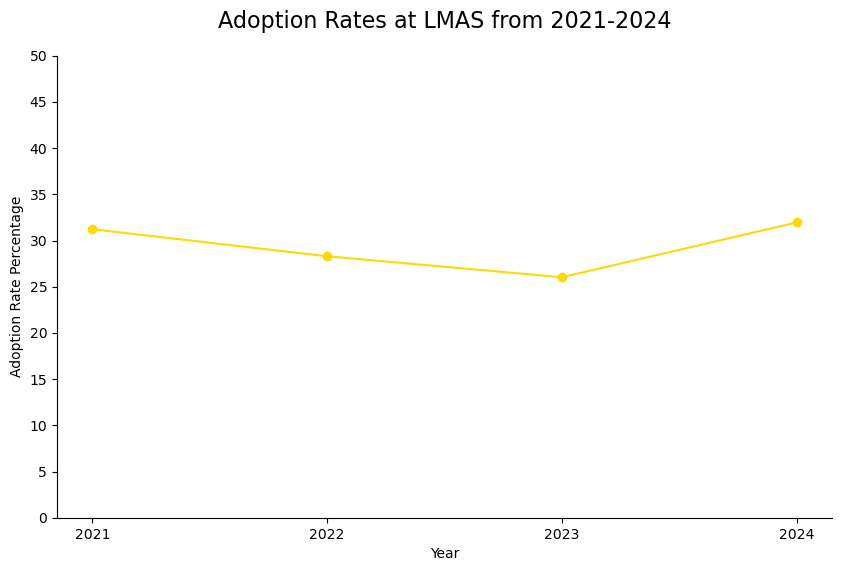

In [39]:
plt.figure(figsize=(10,6))

plt.plot(df_adoption_rates.index, df_adoption_rates.values, color="#ffd904", marker='o')


plt.xlabel("Year")
plt.ylabel("Adoption Rate Percentage")
plt.title("Adoption Rates at LMAS from 2021-2024", fontsize=16, pad=20)


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1.0))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=5.0))


plt.ylim(0, 50)

plt.show()

For the adoption rate, I used similar methods as I did for the return rate, using the first function as a sanity check on the math that the later function provides. I am confident I have a good calculation for this. Now, to compare the two.

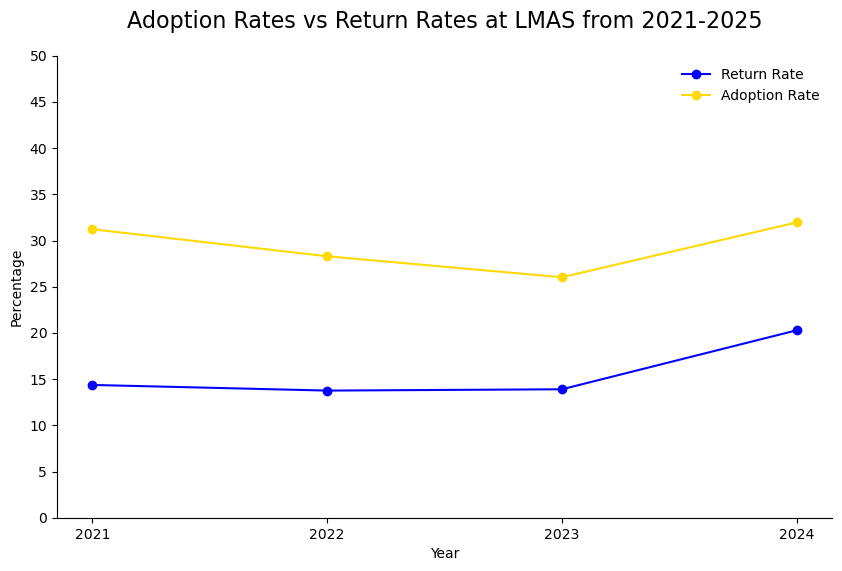

In [40]:
plt.figure(figsize=(10,6))

plt.plot(df_return_rates.index, df_return_rates.values, color="#0400ff", marker='o')
plt.plot(df_adoption_rates.index, df_adoption_rates.values, color="#ffd904", marker='o')


plt.xlabel("Year")
plt.ylabel("Percentage")
plt.title("Adoption Rates vs Return Rates at LMAS from 2021-2025", fontsize=16, pad=20)


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_locator(ticker.MultipleLocator(base=1.0))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base=5.0))

plt.legend(['Return Rate', 'Adoption Rate'], loc='upper right', frameon=False)


plt.ylim(0, 50)

plt.show()

The return rate has remained lower than the adoption rate, which is good! But it seems like they are headed towards meeting each other. I chose a line graph again to display this information as it shows trends over time best, but kept it at the same scale as the original graph. I added a legend to make it clear which line is which.

Both return rate and adoption rate are important metrics, as they show the animal's movement to and from the shelter.

#### Return Reasons

I'd like to know why animals are being returned. There is a surrender reason column and an intake type column that I can use to find out.

In [41]:
surrender_reason_counts = lmas_df.groupby(lmas_df['animal_id'])[['surrender_reason', 'intake_type', 'intake_subtype']].value_counts()

df_surrender_reason_counts = lmas_df.join(surrender_reason_counts.rename('animal_counts'), on=['animal_id', 'surrender_reason', 'intake_type', 'intake_subtype'])

df_surrender_reason_returns = df_surrender_reason_counts[df_surrender_reason_counts['animal_id'].duplicated(keep=False)]

df_surrender_reasons_returns_drop_animal_counts = df_surrender_reason_returns.drop('animal_counts', axis=1)

df_surrender_reasons_only_returns = df_surrender_reasons_returns_drop_animal_counts.groupby(df_surrender_reasons_returns_drop_animal_counts['surrender_reason'])[['intake_type', 'intake_subtype']].value_counts()

df_surrender_reasons_only_returns_counts = df_surrender_reason_returns.join(df_surrender_reasons_only_returns.rename('intake_reason_counts'), on=['surrender_reason', 'intake_type', 'intake_subtype'])

df_surrender_reasons_only_returns_counts_no_nulls = df_surrender_reasons_only_returns_counts.dropna()

df_final_surrender_reasons_counts = df_surrender_reasons_only_returns_counts_no_nulls.groupby(df_surrender_reasons_only_returns_counts_no_nulls['surrender_reason'])[['intake_type', 'intake_subtype', 'intake_reason_counts']].value_counts().reset_index()

In [42]:
import plotly.express as px


fig = px.sunburst(
    df_final_surrender_reasons_counts,
    path=['surrender_reason', 'intake_type', 'intake_subtype'],
    values='intake_reason_counts',
    color='surrender_reason',
    title='Return Reasons at Louisville Metro Animal Services',
    width= 1000,
    height=1000
)

fig.update_layout(
    margin=dict(t=50, l=25, r=25, b=25),
    uniformtext=dict(minsize=10)
)

fig.show()

There are three categories of reasons, and a lot of them. I decided a Sunburst chart would be best after doing some experimentation between it and a Sankey chart. It's not fully readable at a glance, but you can hover over fields to get additional information in a tooltip. I decided to leave the color scheme as default as there really are a lot of values and I don't think I could create anything more friendly. The Sunburst chart definitely demonstrates that stray is the top reason for an animal being taken in. I do question how each type is chosen as "stray" from "surrender_reason" appears in "intake_type," so perhaps whoever is doing the data entry isn't clear on what column means what.

Some other notes:

OTC commonly means "Over the Counter," meaning the animal was brought to the shelter by a community member rather than picked up by animal control.

Field means the animal was picked up by animal control.

#### Intake According to the Season

Next I would like to figure out how intake compares to the seasons of the year. For this, I will use Dec-Feb as Winter, Mar-May as Spring, Jun-Aug as Summer, and Sept-Nov as Fall.

In [43]:
month_to_season = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring',
    5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall', 12: 'Winter'
}

lmas_df['season'] = lmas_df['intake_date'].dt.month.map(month_to_season)

lmas_df['month_num'] = lmas_df['intake_date'].dt.month

lmas_df['intake_year'] = lmas_df['intake_date'].dt.year

df_by_month = lmas_df.sort_values('month_num').drop(columns=['month_num'])

season_counts = lmas_df.groupby(lmas_df['season'])['intake_year'].value_counts()

df_season_counts = lmas_df.join(season_counts.rename('season_counts'), on=['season', 'intake_year'])

df_season_counts_pivot = df_season_counts.pivot_table(index='season', columns='intake_year', values='season_counts')

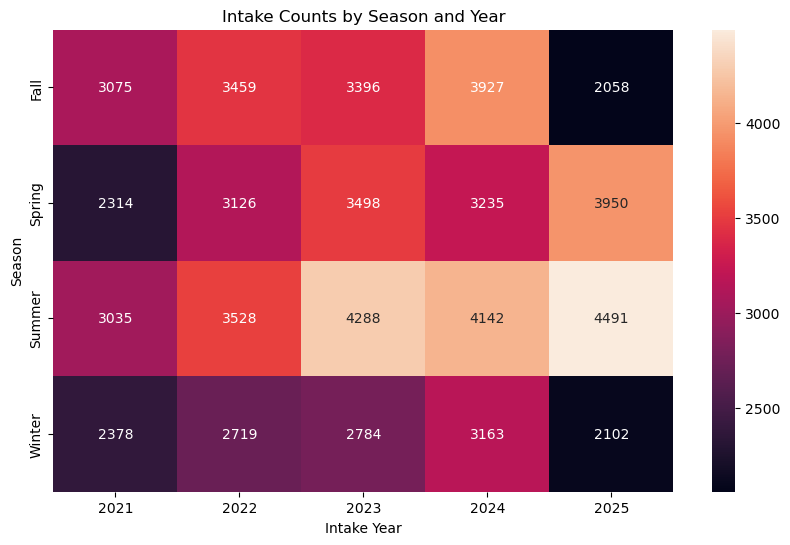

In [44]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(df_season_counts_pivot, cmap='rocket', annot=True, fmt='.0f')
plt.title('Intake Counts by Season and Year')
plt.xlabel('Intake Year')
plt.ylabel('Season')

plt.show()

Summer seems to be the winner, at least in 2023-2025, for most animal intakes. The heatmap is a good way of displaying this information at a glance, and I chose Seaborn's "rocket" color scheme because it was easier for my eyes to detect the patterns. I decided that the colors were varied enough that I didn't need space between the boxes.

Knowing the time of year that there are more intakes helps to make sure there are appropriate staffing levels to handle the influx. It also helps to develop a few theories. For example, maybe summer intake levels are higher because people are more likely to leave their pet unattended in a backyard and the pet escapes? This could inform strategies with the public for keeping their animals safe and at home.

#### Intake by Zip Code

Next I'd like to explore intake by zip code, and will eventually connect this to median income from the ACS census data.

In [45]:
#Reminder of columns I can use:

lmas_df.dtypes

kennel                         str
animal_id                      str
jurisdiction                   str
intake_type                    str
intake_subtype                 str
intake_date         datetime64[us]
surrender_reason               str
out_type                       str
out_subtype                    str
out_date            datetime64[us]
animal_type                    str
sex                            str
bites                          str
size                           str
color                          str
breed                          str
source_zip_code                str
season                         str
month_num                    int32
intake_year                  int32
dtype: object

In [46]:
source_zip_code_counts = lmas_df.groupby(lmas_df['source_zip_code']).count()
source_zip_code_counts

,kennel,animal_id,jurisdiction,intake_type,intake_subtype,intake_date,surrender_reason,out_type,out_subtype,out_date,animal_type,sex,bites,size,color,breed,season,month_num,intake_year
source_zip_code,,,,,,,,,,,,,,,,,,,
04374,1,1,0,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1
06705,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
06706,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
08048,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
13409,2,2,0,2,2,2,0,0,0,0,2,2,0,1,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90274,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
90602,1,1,0,1,1,1,0,0,0,0,1,1,0,1,1,1,1,1,1
92120,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [47]:
jurisdiction_zip_code_counts = lmas_df.groupby(lmas_df['jurisdiction']).count()
jurisdiction_zip_code_counts

,kennel,animal_id,intake_type,intake_subtype,intake_date,surrender_reason,out_type,out_subtype,out_date,animal_type,sex,bites,size,color,breed,source_zip_code,season,month_num,intake_year
jurisdiction,,,,,,,,,,,,,,,,,,,
40023,53,53,53,53,53,53,53,48,53,53,53,53,53,53,53,53,53,53,53
40059,111,111,111,111,111,111,111,98,111,111,111,111,111,111,111,106,111,111,111
40118,1010,1010,1010,1009,1010,1010,1005,753,1005,1010,1010,1009,1010,1010,1010,1007,1010,1010,1010
40177,51,51,51,51,51,51,51,32,51,51,51,51,51,51,51,51,51,51,51
40202,455,455,455,453,455,455,446,404,446,455,455,455,455,455,455,452,455,455,455
40203,1663,1663,1663,1660,1663,1663,1654,1372,1654,1663,1663,1663,1663,1663,1663,1643,1663,1663,1663
40204,612,612,612,609,612,612,608,483,609,612,612,612,612,612,612,607,612,612,612
40205,618,618,618,617,618,618,612,550,613,618,618,618,618,618,618,614,618,618,618
40206,761,761,761,758,761,761,757,664,757,761,761,761,761,761,761,751,761,761,761


After playing around with a couple different variables, I discovered that 'jurisdiction' is actually the zip code. I am unsure of what source_zip_code actually is, as it's often too long to be the trailing four digits that further narrow a zip code. Either way, I will be using jurisdiction for zip code.

In [48]:
filtered_juris_df = lmas_df['jurisdiction'].value_counts()

filtered_juris_df

jurisdiction
40218            5710
40216            3823
40214            3481
40272            3097
40212            3059
40215            2914
40211            2818
40219            2801
40258            2097
40229            2023
40210            1818
40203            1663
40208            1567
40213            1539
40291            1533
40299            1166
40118            1010
40220             911
OUT OF COUNTY     777
40206             761
40228             753
40217             674
40205             618
40204             612
40207             594
40222             589
40245             583
40241             497
40202             455
40223             425
40242             243
40243             219
40209             161
40059             111
40023              53
40177              51
40225              12
Name: count, dtype: int64

The top zip code is 40218. It is worth noting that Louisville Metro Animal Services' shelter is located in 40218. I want to check if "OTC" or "over the counter" type returns are in this jurisdiction.

In [57]:
filtered_surr_reason_df = lmas_df.groupby(['surrender_reason']).size()
filtered_surr_reason_df

surrender_reason
ABANDON        1605
AFRAID           11
AGG ANIMAL      187
AGG FEAR         38
AGG FOOD         31
AGG PEOPLE      300
ALLERGIC         81
ARREST           22
ATTENTION         3
BITES            77
CHASES ANI       48
CHASES PEO        4
CHILD PROB       91
COST             11
CRUELTY         190
DESTRUC IN       41
DESTRUC OT        1
DISOBIDIEN       15
DIVORCE           3
DOA             499
ESCAPES          22
EUTH BEHAV      109
EUTH MED         81
EUTH OLD         21
EUTH OTHER       23
FOSTER RET     7338
FOUND ANIM        2
HOUSE SOIL       20
HYPER           123
ILL              21
INJURED          70
JUMPS UP          2
LANDLORD        101
MOVE             94
NEW BABY          8
NO HOME          91
NO MOM          186
NO TIME          72
NOFRIENDLY        6
OTHER PET       324
OWNER DIED      232
OWNER MED       275
PETMEDICAL      191
RESPONSIBL      505
SHEDS            16
STRAY         37234
TOO BIG          31
TOO MANY        113
TOO OLD           4
TOO

In [58]:
filtered_intake_type_df = lmas_df.groupby(['intake_type']).size()
filtered_intake_type_df

intake_type
CONFISCATE     1340
DISPOSAL        446
EVACUEE           2
FOR TRANSP        8
FOSTER         9798
FOUND          4276
LOST           9182
OWNER SUR      1649
RETURN         1304
STRAY         36663
dtype: int64

In [59]:
filtered_intake_subtype_df = lmas_df.groupby(['intake_subtype']).size()
filtered_intake_subtype_df

intake_subtype
ABANDONED       212
ADOPTION       1256
BITE             36
CHAINING         10
COURT ORD        11
CRUELTY         162
DANGER DOG        8
EUTH REQ        359
EVICTION        199
FIELD          8834
HOSPITAL         68
INTPL VIOL       25
K HUMANE S       12
NEGLECT          88
OTC           29054
OWNER           115
OWNER DIED      118
POLICE          369
POTDANGER         6
RESCUE GRP       11
RESTRAINT        21
RETURN         9766
RETURN 30       138
STRAY           142
VET CLINIC        5
WEB           13456
WILDLIFE          5
dtype: int64

OTC is located in the 'intake_subtype' column.

In [60]:
target_juris = '40218'
target_subtype = 'OTC'
narrowed_intake_subtype_by_juris = lmas_df[(lmas_df['jurisdiction'] == target_juris) & (lmas_df['intake_subtype'] == target_subtype)]
narrowed_intake_subtype_by_juris

,kennel,animal_id,jurisdiction,intake_type,intake_subtype,intake_date,surrender_reason,out_type,out_subtype,out_date,animal_type,sex,bites,size,color,breed,source_zip_code,season,month_num,intake_year
24,C132,A689031,40218,STRAY,OTC,2021-02-08,STRAY,rtf,NaN,2021-02-16,cat,N,N,LARGE,GRAY / WHITE,DOMESTIC LH,40218,Winter,2,2021
25,C309,A689031,40218,STRAY,OTC,2022-10-24,STRAY,rtf,NaN,2022-11-02,cat,N,N,LARGE,GRAY / WHITE,DOMESTIC LH,40218,Fall,10,2022
84,C110,A690932,40218,OWNER SUR,OTC,2021-04-05,OWNER DIED,transfer,RESCUE GRP,2021-04-10,cat,S,N,LARGE,TORTIE / MUTED,DOMESTIC SH,40218,Spring,4,2021
111,C218,A688972,40218,STRAY,OTC,2021-02-07,STRAY,foster,TOO YOUNG,2021-02-07,cat,U,N,KITTN,WHITE,DOMESTIC SH,40218,Winter,2,2021
151,INTAKE,A688435,40218,STRAY,OTC,2021-02-03,STRAY,tnr,CARETAKER,2021-02-04,cat,S,N,MED,BLACK,DOMESTIC SH,40218,Winter,2,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64595,TNR/OUT,A782359,40218,STRAY,OTC,2025-06-10,STRAY,snr,NaN,2025-06-12,cat,S,N,MED,BRN TABBY / WHITE,DOMESTIC SH,40218,Summer,6,2025
64637,FEEDERS PH,A782329,40218,STRAY,OTC,2025-06-10,STRAY,adoption,FEEDERS PH,2025-06-16,cat,N,N,KITTN,GRAY TABBY,DOMESTIC SH,40218,Summer,6,2025
64646,C209,A782684,40218,STRAY,OTC,2025-06-16,STRAY,foster,TIME/SPACE,2025-06-18,cat,M,N,KITTN,LYNX PT,DOMESTIC SH,40218,Summer,6,2025
64647,C209,A782687,40218,STRAY,OTC,2025-06-16,STRAY,foster,TIME/SPACE,2025-06-18,cat,F,N,KITTN,CALICO,DOMESTIC SH,40218,Summer,6,2025


OTC accounts for roughly half of the intake for 40218. This puts 40218 more on level with the next few jurisdictions. However, this does not account for all OTC subtypes in the dataframe, so I am not going to make any changes to separate this data out when comparing zip codes, but I will make note of it. Since jurisdiction is not null for any entries, but there are "OUT OF COUNTY" entries, I will exclude the "OUT OF COUNTY" entries when I map this to the median income, since those out of county zip codes aren't specified.

I think I am comfortable with this data and will start on the process to integrate it with the ACS Census data.